Dataset Link: https://www.kaggle.com/datasets/soheiltehranipour/it-customer-churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.metrics import precision_score, recall_score, f1_score

%matplotlib inline

In [2]:
data = pd.read_csv("IT_customer_churn.csv") 
data.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [4]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data.fillna(0, inplace=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [5]:
# Encoding categorical variables
cat_cols = data.select_dtypes(include=['object', 'str']).columns
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

In [6]:
X = data.drop('Churn', axis=1)
y = data['Churn']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (optional but recommended)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
# Function to plot class distribution
def plot_class_distribution(y, title="Class Distribution"):
    counter = Counter(y)
    plt.figure(figsize=(5,4))
    sns.barplot(x=list(counter.keys()), y=list(counter.values()))
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

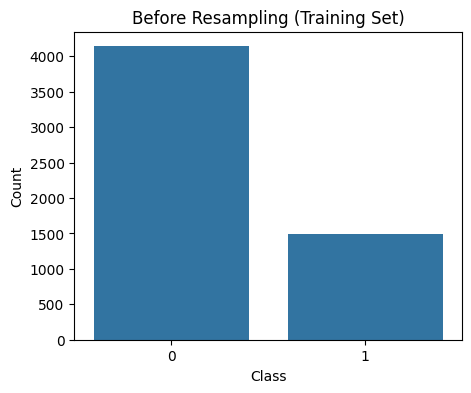

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [8]:
# Approach 1: Train model directly

plot_class_distribution(y_train, "Before Resampling (Training Set)")


# model1 = RandomForestClassifier(random_state=42)
# model1 = SVC(kernel='rbf', probability=True, random_state=42)
model1 = LogisticRegression(max_iter=1000, random_state=42)
# model1 = KNeighborsClassifier(n_neighbors=5)
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
print(classification_report(y_test, y_pred1))


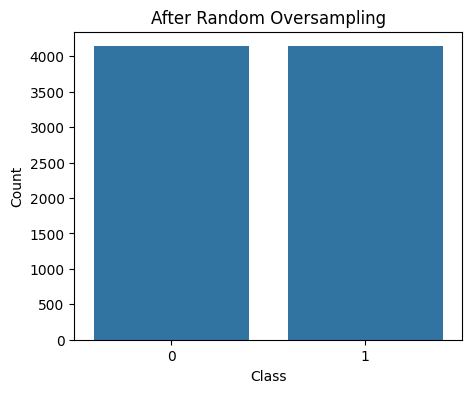

              precision    recall  f1-score   support

           0       0.93      0.73      0.82      1036
           1       0.53      0.84      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



In [9]:
# Approach 2: Random Oversampling
ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)
plot_class_distribution(y_ros, "After Random Oversampling")


# model2 = RandomForestClassifier(random_state=42)
# model2 = SVC(kernel='rbf', probability=True, random_state=42)
model2 = LogisticRegression(max_iter=1000, random_state=42)
# model2 = KNeighborsClassifier(n_neighbors=5)
model2.fit(X_ros, y_ros)
y_pred2 = model2.predict(X_test)
print(classification_report(y_test, y_pred2))


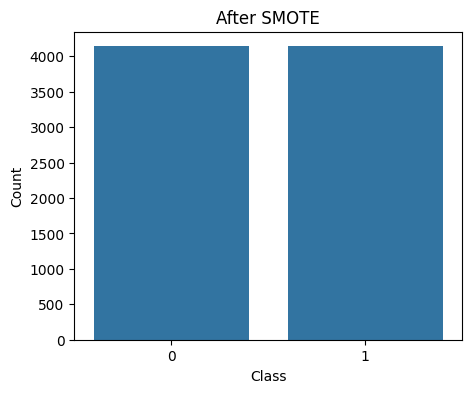

              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.53      0.83      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



In [10]:
# Approach 3: SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

plot_class_distribution(y_smote, "After SMOTE")

# model3 = RandomForestClassifier(random_state=42)
# model3 = SVC(kernel='rbf', probability=True, random_state=42)
model3 = LogisticRegression(max_iter=1000, random_state=42)
# model3 = KNeighborsClassifier(n_neighbors=5)
model3.fit(X_smote, y_smote)
y_pred3 = model3.predict(X_test)
print(classification_report(y_test, y_pred3))

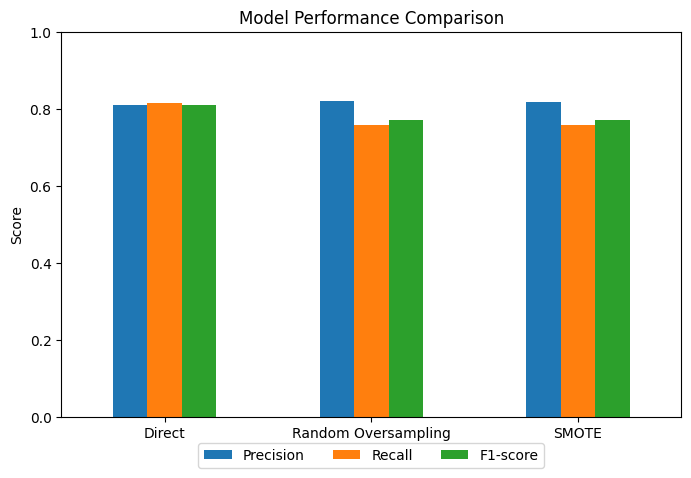

In [11]:
metrics = {
    "Direct": [
        precision_score(y_test, y_pred1, average='weighted'),
        recall_score(y_test, y_pred1, average='weighted'),
        f1_score(y_test, y_pred1, average='weighted'),
    ],
    "Random Oversampling": [
        precision_score(y_test, y_pred2, average='weighted'),
        recall_score(y_test, y_pred2, average='weighted'),
        f1_score(y_test, y_pred2, average='weighted'),
    ],
    "SMOTE": [
        precision_score(y_test, y_pred3, average='weighted'),
        recall_score(y_test, y_pred3, average='weighted'),
        f1_score(y_test, y_pred3, average='weighted'),
    ],
}

metrics_df = pd.DataFrame(metrics, index=["Precision", "Recall", "F1-score"])

metrics_df.T.plot(kind='bar', figsize=(8,5))
plt.title("Model Performance Comparison")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.show()